Install packages


In [1]:
!pip install rdkit transformers torch hestia-good -q


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Download & extract ChEMBL

In [ ]:
# Download ChEMBL v36 SQLite database
!wget -q --show-progress https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/releases/chembl_36/chembl_36_sqlite.tar.gz

# Extract it
!tar -xzf chembl_36_sqlite.tar.gz

# Verify
!ls -lh chembl_36/chembl_36_sqlite/chembl_36.db

chembl_36_sqlite.ta 100%[===================>]   5.23G  33.2MB/s    in 2m 43s  
-rw-r--r-- 1 5012 1101 28G Sep 10  2025 chembl_36/chembl_36_sqlite/chembl_36.db


Query HCRTR1

In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('chembl_36/chembl_36_sqlite/chembl_36.db')

query = """
SELECT
    cs.canonical_smiles,
    act.pchembl_value,
    act.standard_type
FROM activities act
JOIN assays a ON act.assay_id = a.assay_id
JOIN target_dictionary td ON a.tid = td.tid
JOIN compound_structures cs ON act.molregno = cs.molregno
WHERE td.chembl_id = 'CHEMBL5113'
  AND act.pchembl_value IS NOT NULL
  AND act.standard_relation = '='
"""

df = pd.read_sql_query(query, conn)
print(f"Raw records: {len(df)}")
df.head()

Raw records: 10368


,canonical_smiles,pchembl_value,standard_type
0,CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](C)NC(=O)[C@...,4.18,Ki
1,CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](C)NC(=O)[C@...,7.89,Ki
2,CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](C)NC(=O)[C@...,6.57,Ki
3,COc1cc2c(cc1OC)CN(C(=O)C(Cc1ccc(Br)cc1)C(C)(C)...,5.16,IC50
4,COc1cc2c(cc1OC)CN(C(=O)C(Cc1ccccc1)NC(=O)c1cc(...,5.28,IC50


Deduplicate & filter

In [3]:
# Deduplicate: keep median pChEMBL per compound
df_clean = df.groupby('canonical_smiles')['pchembl_value'].median().reset_index()

# Quality filter
df_clean = df_clean[df_clean['pchembl_value'] >= 5].reset_index(drop=True)
print(f"After cleaning: {len(df_clean)} compounds")

After cleaning: 7090 compounds


Histogram of binding affinities

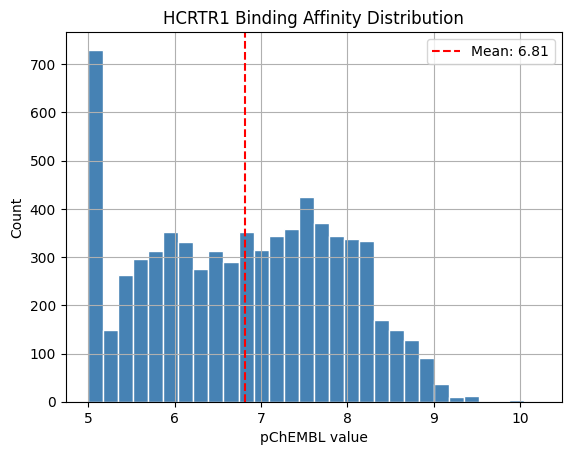

count    7090.000000
mean        6.810774
std         1.118116
min         5.000000
25%         5.886250
50%         6.860000
75%         7.707500
max        10.220000
Name: pchembl_value, dtype: float64


In [4]:
import matplotlib.pyplot as plt

df_clean['pchembl_value'].hist(bins=30, color='steelblue', edgecolor='white')
plt.xlabel('pChEMBL value')
plt.ylabel('Count')
plt.title('HCRTR1 Binding Affinity Distribution')
plt.axvline(df_clean['pchembl_value'].mean(), color='red', linestyle='--',
            label=f"Mean: {df_clean['pchembl_value'].mean():.2f}")
plt.legend()
plt.show()
print(df_clean['pchembl_value'].describe())

Regression vs classification

In [5]:
threshold = 7.0
n_active = (df_clean['pchembl_value'] >= threshold).sum()
n_total = len(df_clean)
print(f"Active (>= {threshold}): {n_active} ({100*n_active/n_total:.1f}%)")
print(f"Inactive (< {threshold}): {n_total - n_active} ({100*(n_total-n_active)/n_total:.1f}%)")
print("Decision: regression (continuous pChEMBL, ~50/50 split confirms no strong threshold)")

Active (>= 7.0): 3275 (46.2%)
Inactive (< 7.0): 3815 (53.8%)
Decision: regression (continuous pChEMBL, ~50/50 split confirms no strong threshold)


Scaffold analysis

In [6]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    return None

df_clean['scaffold'] = df_clean['canonical_smiles'].apply(get_scaffold)
print(f"Unique scaffolds: {df_clean['scaffold'].nunique()} out of {len(df_clean)} compounds")
print(f"Top 5 most common scaffolds:\n{df_clean['scaffold'].value_counts().head()}")

Unique scaffolds: 2182 out of 7090 compounds
Top 5 most common scaffolds:
scaffold
O=C(c1ccccc1-n1nccn1)N1CCCC1c1nc2ccccc2[nH]1      239
O=C(c1ncsc1-c1ccccc1)N1CCCC1c1nc2ccccc2[nH]1      217
O=C(c1ccccc1-n1nccn1)N1CCCC1c1nc(-c2ccccc2)no1    169
O=C(c1ccccc1-c1ccccc1)N1CCCC1c1nc2ccccc2[nH]1     137
O=C(c1ccccc1-n1nccn1)N1CCCC(Oc2ccccn2)C1          133
Name: count, dtype: int64


PCA

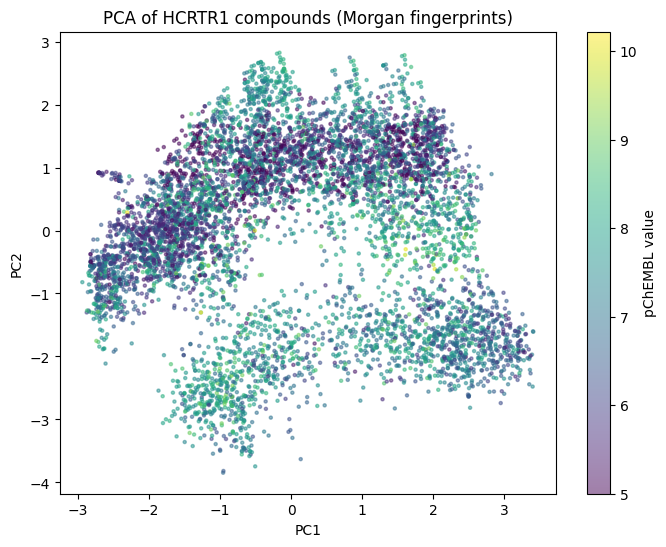

In [7]:
import numpy as np
from rdkit.Chem import AllChem
from sklearn.decomposition import PCA

mols = [Chem.MolFromSmiles(s) for s in df_clean['canonical_smiles']]
fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048) for m in mols if m is not None]
X = np.array(fps)

pca = PCA(n_components=2)
coords = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sc = plt.scatter(coords[:,0], coords[:,1], c=df_clean['pchembl_value'],
                 cmap='viridis', alpha=0.5, s=5)
plt.colorbar(sc, label='pChEMBL value')
plt.title('PCA of HCRTR1 compounds (Morgan fingerprints)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()

ChemBERTa embeddings

In [8]:
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained("DeepChem/ChemBERTa-77M-MLM")
model = AutoModel.from_pretrained("DeepChem/ChemBERTa-77M-MLM")
model.eval()

def get_embedding(smiles):
    tokens = tokenizer(smiles, return_tensors='pt', truncation=True,
                       max_length=512, padding=True)
    with torch.no_grad():
        output = model(**tokens)
    return output.last_hidden_state[:,0,:].squeeze().numpy()

print("Generating embeddings...")
embeddings = np.array([get_embedding(s) for s in df_clean['canonical_smiles']])
print(f"Embeddings shape: {embeddings.shape}")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Generating embeddings...
Embeddings shape: (7090, 384)


ChemBERTa-2 + MLP (Random Split — Pilot)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, df_clean['pchembl_value'].values,
    test_size=0.2, random_state=42
)

mlp = MLPRegressor(hidden_layer_sizes=(256, 128), max_iter=200, random_state=42, verbose=True)
mlp.fit(X_train, y_train)

y_pred_random = mlp.predict(X_test)
y_test_random = y_test
r_random, _ = pearsonr(y_test_random, y_pred_random)
rmse_random = np.sqrt(mean_squared_error(y_test_random, y_pred_random))

print(f"\nRandom split | Pearson R: {r_random:.3f} | RMSE: {rmse_random:.3f}")

Iteration 1, loss = 3.94213055
Iteration 2, loss = 0.52147382
Iteration 3, loss = 0.41043245
Iteration 4, loss = 0.37206290
Iteration 5, loss = 0.34953969
Iteration 6, loss = 0.33281682
Iteration 7, loss = 0.31780822
Iteration 8, loss = 0.30676104
Iteration 9, loss = 0.29500893
Iteration 10, loss = 0.28239156
Iteration 11, loss = 0.27219794
Iteration 12, loss = 0.26496339
Iteration 13, loss = 0.26116355
Iteration 14, loss = 0.24909391
Iteration 15, loss = 0.24257904
Iteration 16, loss = 0.23290260
Iteration 17, loss = 0.23151385
Iteration 18, loss = 0.22434771
Iteration 19, loss = 0.22044748
Iteration 20, loss = 0.21466756
Iteration 21, loss = 0.21186779
Iteration 22, loss = 0.21697325
Iteration 23, loss = 0.20612139
Iteration 24, loss = 0.20329570
Iteration 25, loss = 0.20167672
Iteration 26, loss = 0.20451245
Iteration 27, loss = 0.19334775
Iteration 28, loss = 0.18797330
Iteration 29, loss = 0.19481139
Iteration 30, loss = 0.19167432
Iteration 31, loss = 0.18367259
Iteration 32, los

Scaffold-Based Split (hestia ccpart, Tanimoto 0.4)

In [10]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.ML.Cluster import Butina
import numpy as np

# Compute Morgan fingerprints
fps = []
for smi in df_clean['canonical_smiles']:
    mol = Chem.MolFromSmiles(smi)
    fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048))

# Compute Tanimoto distance matrix (upper triangle)
nfps = len(fps)
dists = []
for i in range(1, nfps):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
    dists.extend([1 - s for s in sims])

# Butina clustering (distance cutoff 0.6 = Tanimoto similarity 0.4)
clusters = Butina.ClusterData(dists, nfps, 0.6, isDistData=True)

# Assign cluster IDs
cluster_ids = np.zeros(nfps, dtype=int)
for cid, cluster in enumerate(clusters):
    for idx in cluster:
        cluster_ids[idx] = cid

# 80/20 split at cluster level (no scaffold leakage)
unique_clusters = np.unique(cluster_ids)
np.random.seed(42)
np.random.shuffle(unique_clusters)
n_test = int(0.2 * len(unique_clusters))
test_clusters = set(unique_clusters[:n_test])

train_idx = np.array([i for i in range(nfps) if cluster_ids[i] not in test_clusters])
test_idx  = np.array([i for i in range(nfps) if cluster_ids[i] in test_clusters])

print(f"Clusters: {len(unique_clusters)}")
print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")

Clusters: 339
Train: 5898 | Test: 1192


ChemBERTa-2 + MLP (Scaffold Split)

In [11]:
from sklearn.neural_network import MLPRegressor
from scipy.stats import pearsonr
import numpy as np

X = embeddings
y = df_clean['pchembl_value'].values

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

model = MLPRegressor(hidden_layer_sizes=(256, 128), max_iter=200, random_state=42)
model.fit(X_train, y_train)

y_pred_scaffold = model.predict(X_test)
y_test_scaffold = y_test
r_scaffold, _ = pearsonr(y_test_scaffold, y_pred_scaffold)
rmse_scaffold = np.sqrt(np.mean((y_test_scaffold - y_pred_scaffold) ** 2))

print(f"Scaffold split | Pearson R: {r_scaffold:.3f} | RMSE: {rmse_scaffold:.3f}")

Scaffold split | Pearson R: 0.623 | RMSE: 0.788


Scatterplot of predicted vs ground truth pChEMBL values for each model

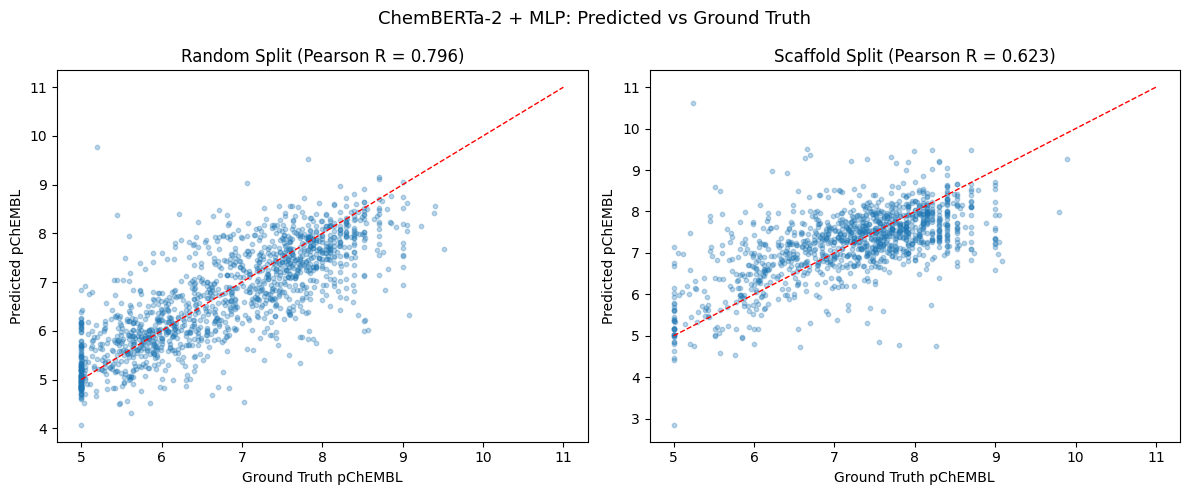

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_random, y_pred_random, alpha=0.3, s=10)
axes[0].plot([5, 11], [5, 11], 'r--', linewidth=1)
axes[0].set_xlabel('Ground Truth pChEMBL')
axes[0].set_ylabel('Predicted pChEMBL')
axes[0].set_title(f'Random Split (Pearson R = {r_random:.3f})')

axes[1].scatter(y_test_scaffold, y_pred_scaffold, alpha=0.3, s=10)
axes[1].plot([5, 11], [5, 11], 'r--', linewidth=1)
axes[1].set_xlabel('Ground Truth pChEMBL')
axes[1].set_ylabel('Predicted pChEMBL')
axes[1].set_title(f'Scaffold Split (Pearson R = {r_scaffold:.3f})')

plt.suptitle('ChemBERTa-2 + MLP: Predicted vs Ground Truth', fontsize=13)
plt.tight_layout()
plt.show()

Config log

In [13]:
import pandas as pd
import os

config = {
    'model': 'DeepChem/ChemBERTa-77M-MLM',
    'embedding_dim': embeddings.shape[1],
    'regressor': 'MLP (256, 128)',
    'max_iter': 200,
    'split_random_r': r_random,
    'split_random_rmse': rmse_random,
    'split_scaffold_r': r_scaffold,
    'split_scaffold_rmse': rmse_scaffold,
    'n_compounds': len(df_clean),
    'target': 'HCRTR1',
    'notes': 'ChemBERTa-2 (77M), no protein embedding'
}

log_path = 'config_log.csv'
df_log = pd.DataFrame([config])
if os.path.exists(log_path):
    df_log = pd.concat([pd.read_csv(log_path), df_log], ignore_index=True)
df_log.to_csv(log_path, index=False)
print(df_log)

                        model  embedding_dim       regressor  max_iter  \
0  DeepChem/ChemBERTa-77M-MLM            384  MLP (256, 128)       200   

   split_random_r  split_random_rmse  split_scaffold_r  split_scaffold_rmse  \
0        0.796015           0.697168          0.623187             0.787517   

   n_compounds  target                                    notes  
0         7090  HCRTR1  ChemBERTa-2 (77M), no protein embedding  
